In [4]:
# -----------------------------------------------------------
# Installing Kaggle API
# -----------------------------------------------------------
!pip install kaggle -q

In [6]:
# -----------------------------------------------------------
# Creating Kaggle Directory
# -----------------------------------------------------------
import os

os.makedirs("/root/.kaggle", exist_ok=True)

print(" Kaggle directory created")

In [7]:
# -----------------------------------------------------------
# Downloading Brain Tumor MRI Dataset
# -----------------------------------------------------------
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:09<00:00, 17.8MB/s]



In [10]:
# -----------------------------------------------------------
# Extracting Dataset
# -----------------------------------------------------------
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_data

replace brain_tumor_data/Testing/glioma/Te-gl_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [11]:
# ============================================================
# STEP 1: IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training set distribution:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images
  TOTAL: 5600

Test set distribution:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images
  TOTAL: 1600


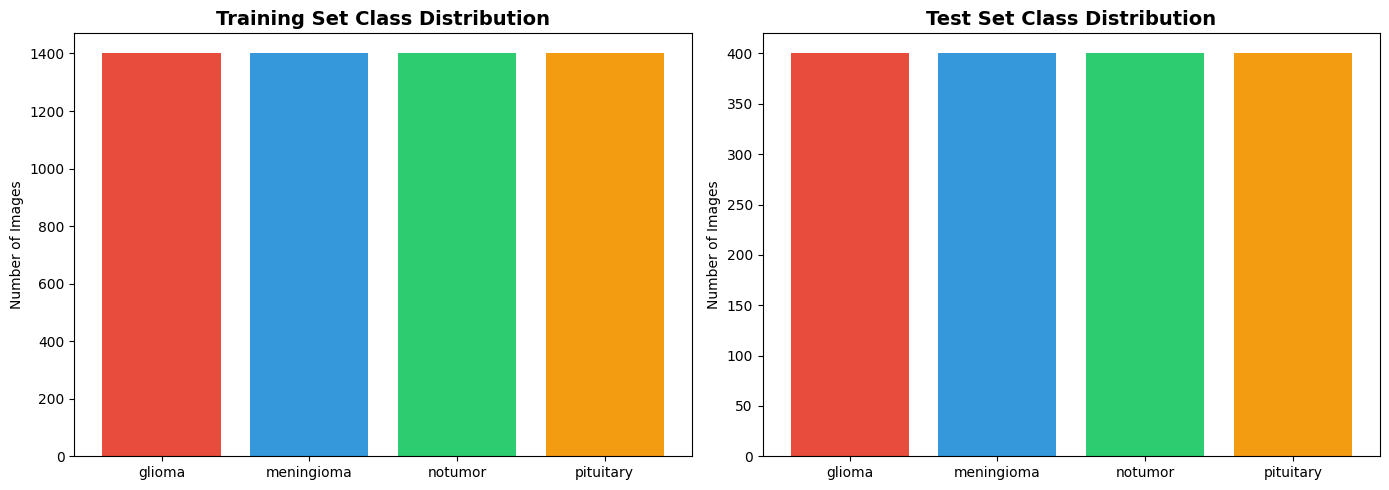

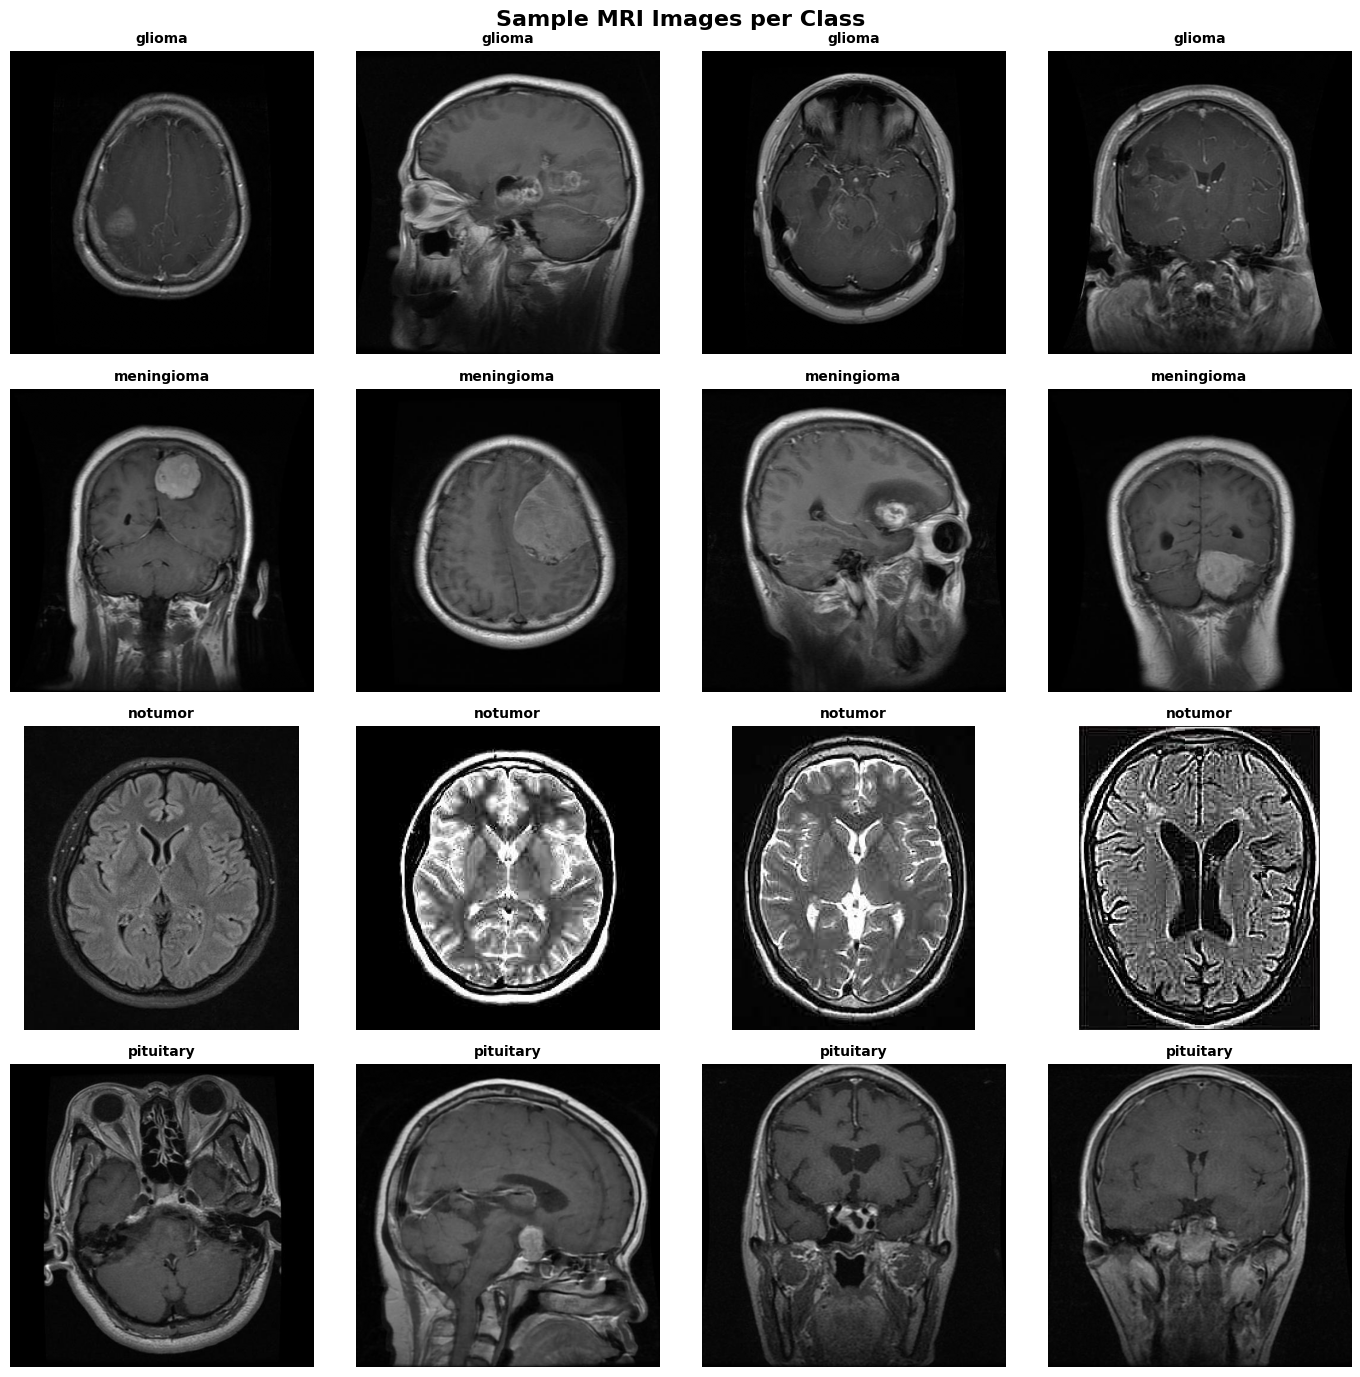

In [12]:
# ============================================================
# STEP 2: DATA UNDERSTANDING & VISUALIZATION
# ============================================================
TRAIN_DIR = '/content/brain_tumor_data/Training'
TEST_DIR  = '/content/brain_tumor_data/Testing'

classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)

# Count images per class
train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(TEST_DIR,  c))) for c in classes}

print("\nTraining set distribution:")
for c, n in train_counts.items():
    print(f"  {c}: {n} images")
print(f"  TOTAL: {sum(train_counts.values())}")

print("\nTest set distribution:")
for c, n in test_counts.items():
    print(f"  {c}: {n} images")
print(f"  TOTAL: {sum(test_counts.values())}")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(train_counts.keys(), train_counts.values(), color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[1].bar(test_counts.keys(), test_counts.values(), color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Images')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample images
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_dir)[:4]
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_dir, img_name)
        img = plt.imread(img_path)
        axes[i][j].imshow(img, cmap='gray' if len(img.shape)==2 else None)
        axes[i][j].set_title(f'{cls}', fontsize=10, fontweight='bold')
        axes[i][j].axis('off')
plt.suptitle('Sample MRI Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training samples: 4480
Validation samples: 1120
Test samples: 1600


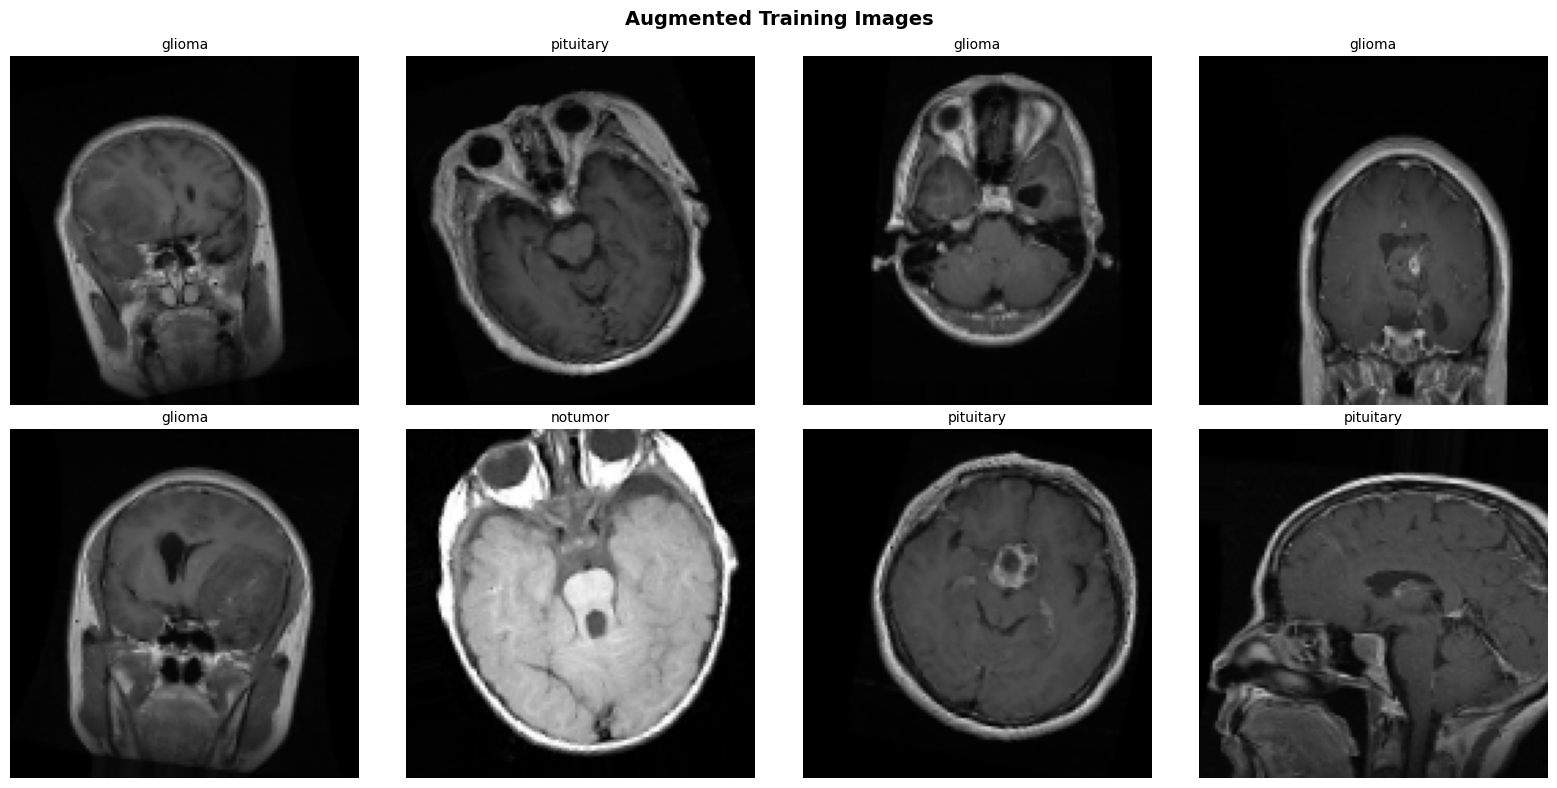

In [13]:
# ============================================================
# STEP 3: DATA GENERATORS WITH AUGMENTATION
# ============================================================
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

# Test/Val generator - only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(classes)
print(f"\nClasses: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

# Visualize augmented images
sample_batch = next(train_generator)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[0][i])
    label_idx = np.argmax(sample_batch[1][i])
    ax.set_title(classes[label_idx], fontsize=10)
    ax.axis('off')
plt.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# HELPER: Plot training curves
# ============================================================
def plot_history(history, model_name, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss',     color='#e74c3c', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='#3498db', linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Loss Curve', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#2ecc71', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#f39c12', linewidth=2, linestyle='--')
    axes[1].set_title(f'{model_name} — Accuracy Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# HELPER: Evaluate model
# ============================================================
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print('='*50)
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return y_pred, y_true


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)


Training Baseline CNN...
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 301ms/step - accuracy: 0.5857 - loss: 0.9363 - val_accuracy: 0.6839 - val_loss: 0.7077 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 232ms/step - accuracy: 0.7234 - loss: 0.6688 - val_accuracy: 0.7277 - val_loss: 0.6682 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 267ms/step - accuracy: 0.7585 - loss: 0.6096 - val_accuracy: 0.7705 - val_loss: 0.5601 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 233ms/step - accuracy: 0.7960 - loss: 0.5184 - val_accuracy: 0.7589 - val_loss: 0.5745 - learning_rate: 0.0010
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 234ms/step - accuracy: 0.7944 - loss: 0.4991 - val_accuracy: 0.8036 - val_loss: 0.4706 - learning_rate: 0.0010
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.8058 - loss: 0.4772 - val_accuracy: 0.8071 - val_loss: 0.4762 - learning_rate: 0.0010
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 

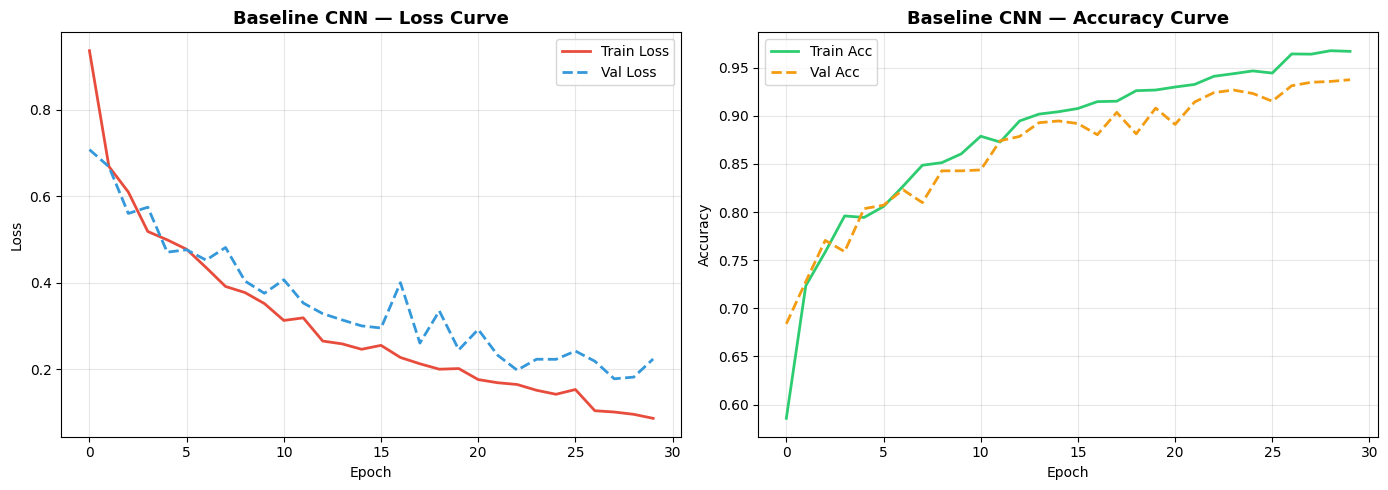


Baseline Test Accuracy: 85.19%
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step

Evaluation: Baseline CNN
              precision    recall  f1-score   support

      glioma       0.96      0.66      0.78       400
  meningioma       0.86      0.80      0.83       400
     notumor       0.72      1.00      0.84       400
   pituitary       0.95      0.95      0.95       400

    accuracy                           0.85      1600
   macro avg       0.87      0.85      0.85      1600
weighted avg       0.87      0.85      0.85      1600



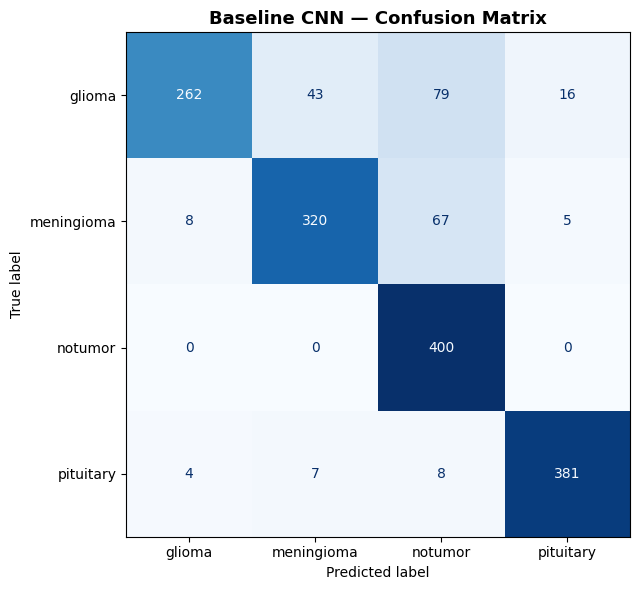

(array([1, 0, 0, ..., 3, 3, 3]), array([0, 0, 0, ..., 3, 3, 3], dtype=int32))

In [14]:
# ============================================================
# PART A — STEP 1: BASELINE CNN MODEL (3 Conv + 3 FCN)
# ============================================================
def build_baseline_cnn(num_classes):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(128,128,3)),
        layers.MaxPooling2D(2,2),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        # Conv Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

# Callbacks
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("\nTraining Baseline CNN...")
start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_baseline,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)")

plot_history(history_baseline, 'Baseline CNN', 'history_baseline')

# Evaluate baseline
_, baseline_acc = baseline_model.evaluate(test_generator, verbose=0)
print(f"\nBaseline Test Accuracy: {baseline_acc*100:.2f}%")
evaluate_model(baseline_model, test_generator, 'Baseline CNN')


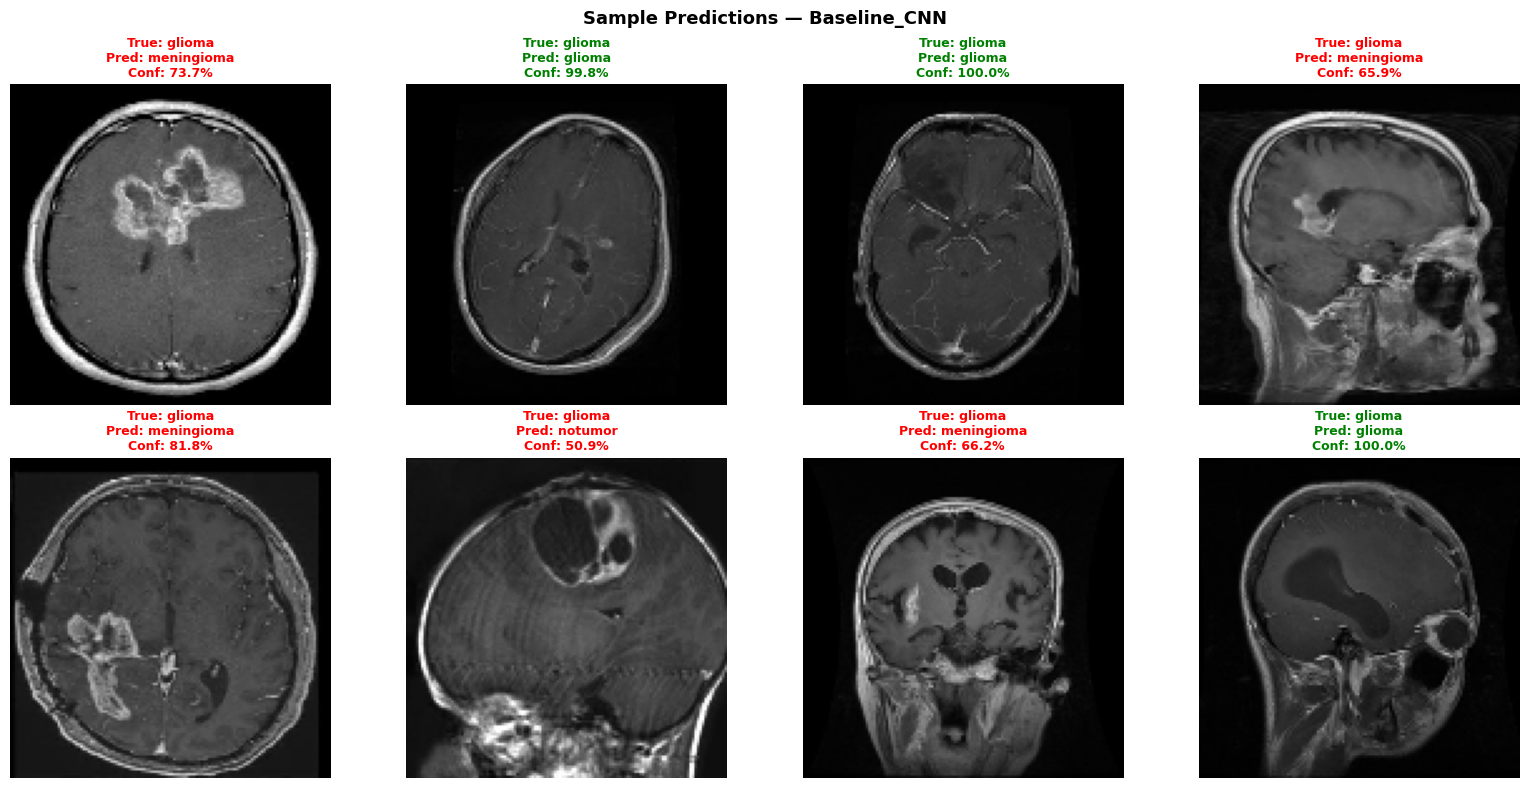

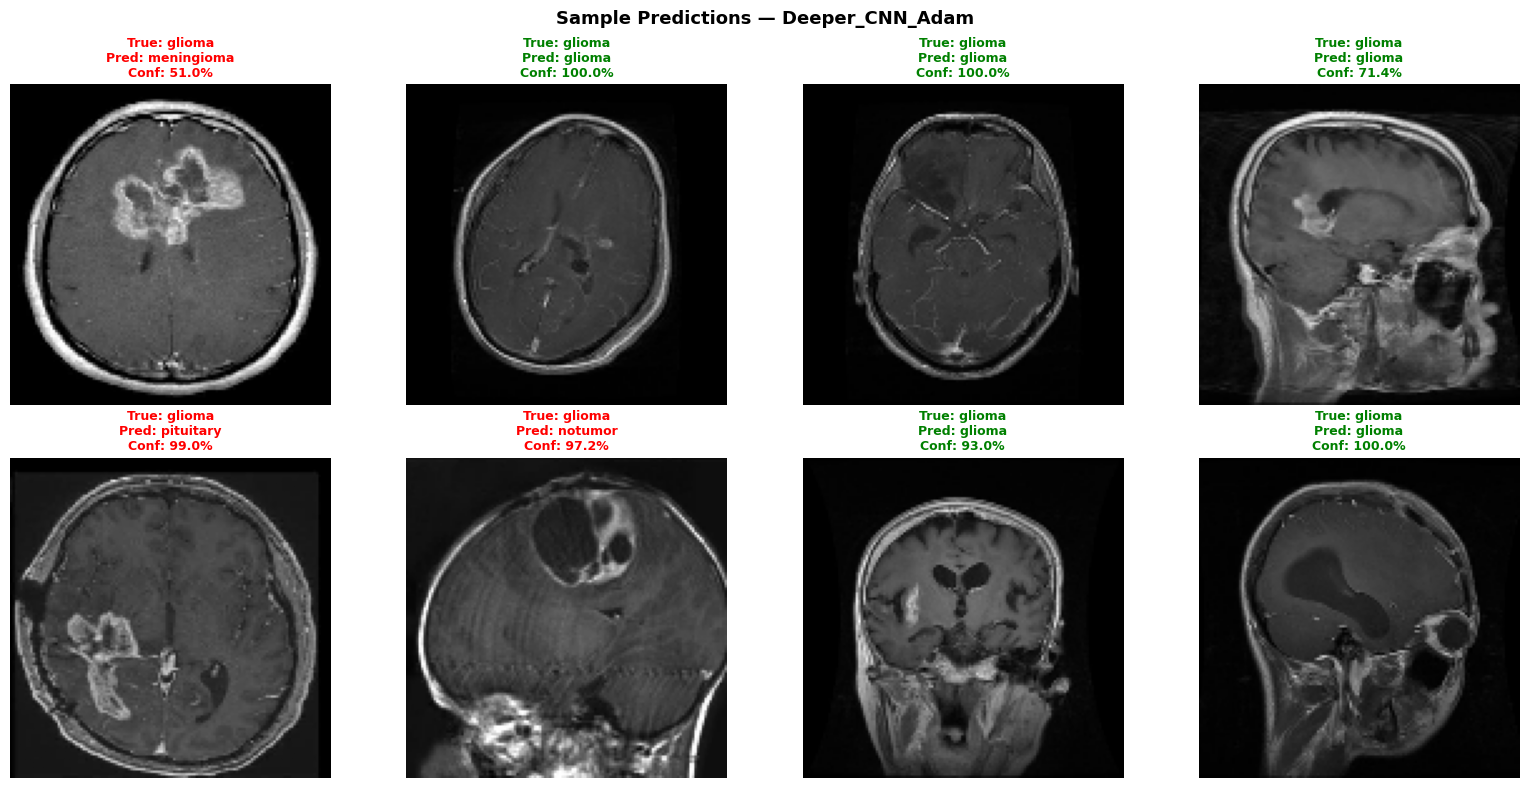

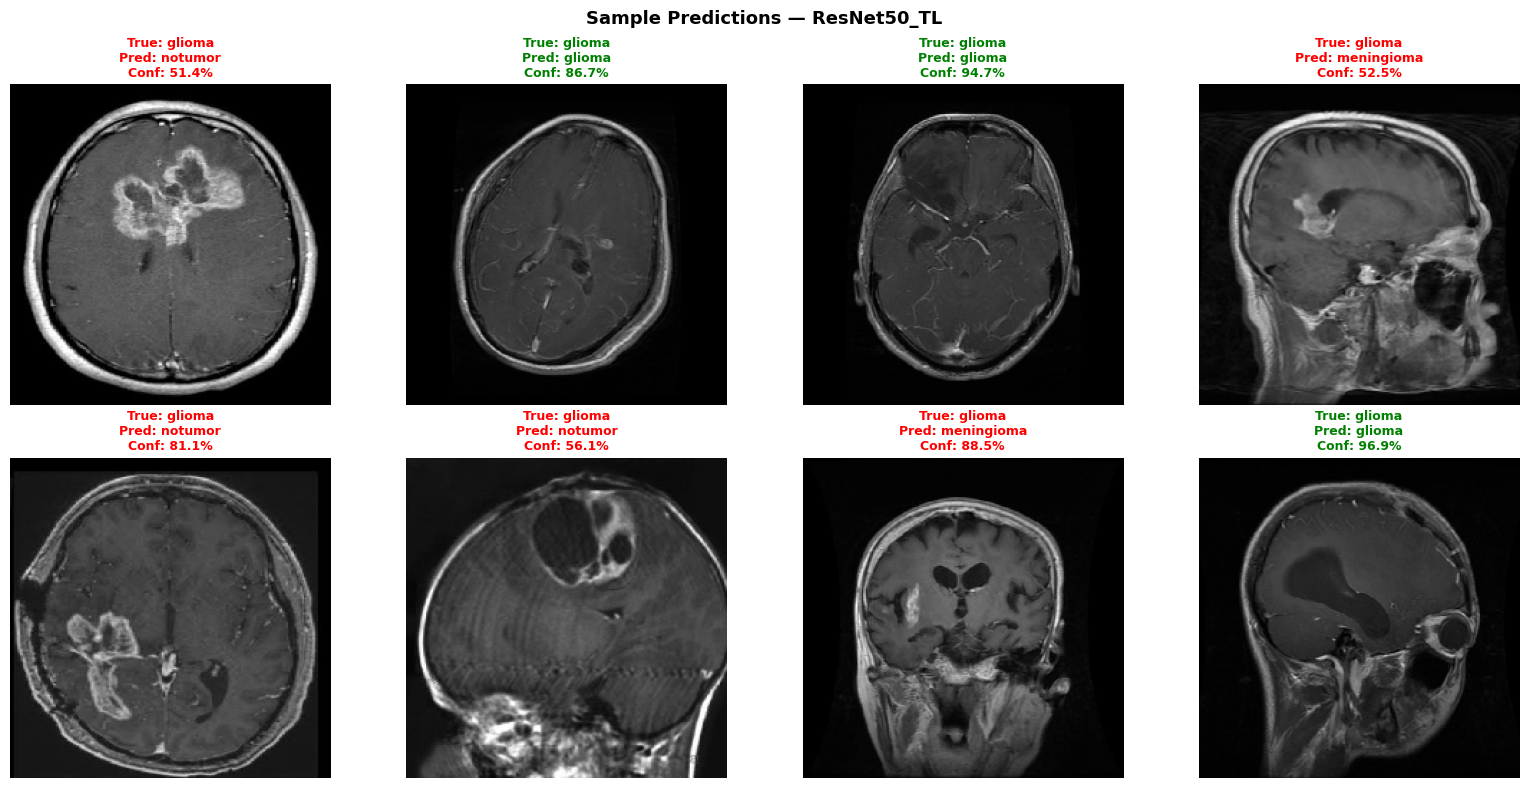

In [19]:
# Inference on sample test images
def visualize_predictions(model, generator, class_names, model_name):
    generator.reset()
    images, labels = next(generator)
    predictions = model.predict(images, verbose=0)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i])
        true_label = class_names[np.argmax(labels[i])]
        pred_label = class_names[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f'Sample Predictions — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'inference_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(baseline_model, test_generator, classes, 'Baseline_CNN')
visualize_predictions(deeper_model_adam, test_generator, classes, 'Deeper_CNN_Adam')
visualize_predictions(tl_model, tl_test_gen, classes, 'ResNet50_TL')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 9,730,084 (37.12 MB)

 Trainable params: 9,728,100 (37.11 MB)

 Non-trainable params: 1,984 (7.75 KB)


Training Deeper CNN (Adam)...
Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 60s 285ms/step - accuracy: 0.6196 - loss: 0.9429 - val_accuracy: 0.2500 - val_loss: 2.9522 - learning_rate: 0.0010
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.7076 - loss: 0.7464 - val_accuracy: 0.3187 - val_loss: 1.7618 - learning_rate: 0.0010
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.7533 - loss: 0.6382 - val_accuracy: 0.3795 - val_loss: 1.4428 - learning_rate: 0.0010
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 242ms/step - accuracy: 0.7500 - loss: 0.6290 - val_accuracy: 0.4464 - val_loss: 1.4291 - learning_rate: 0.0010
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 248ms/step - accuracy: 0.7871 - loss: 0.5705 - val_accuracy: 0.7393 - val_loss: 0.6727 - learning_rate: 0.0010
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 243ms/step - accuracy: 0.8036 - loss: 0.5205 - val_accuracy: 0.7259 - val_loss: 0.7867 - learning_rate: 0.0010
Epoch 7/40
140/140 ━━━━━━━━━━━━━━━━━━━━

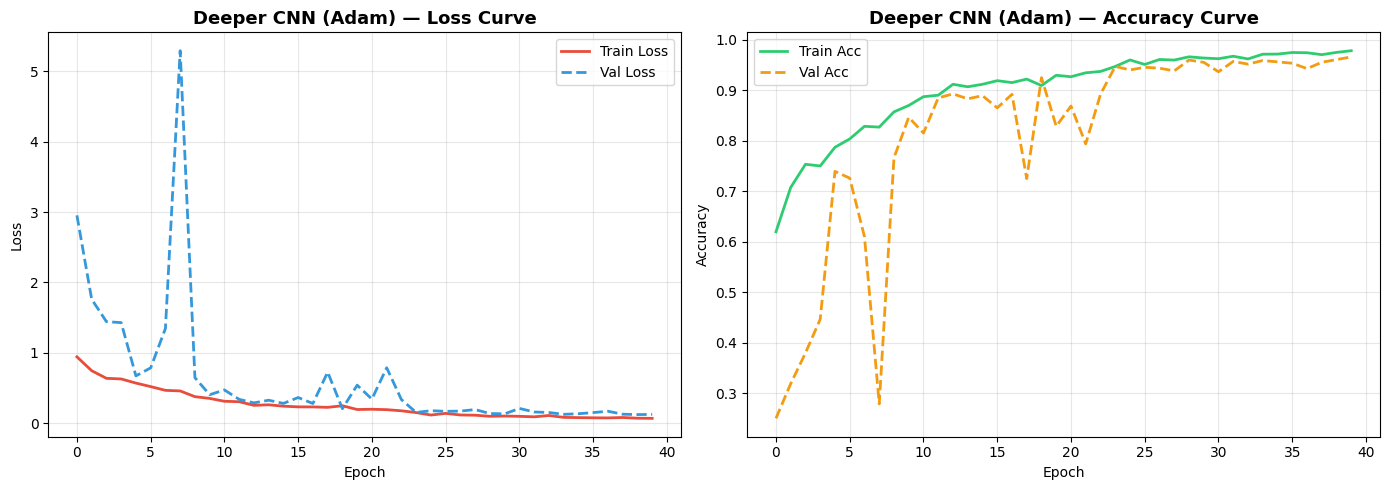

Deeper CNN (Adam) Test Accuracy: 91.56%
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step

Evaluation: Deeper CNN Adam
              precision    recall  f1-score   support

      glioma       0.97      0.79      0.87       400
  meningioma       0.95      0.88      0.91       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.92      1.00      0.95       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.91      1600
weighted avg       0.92      0.92      0.91      1600



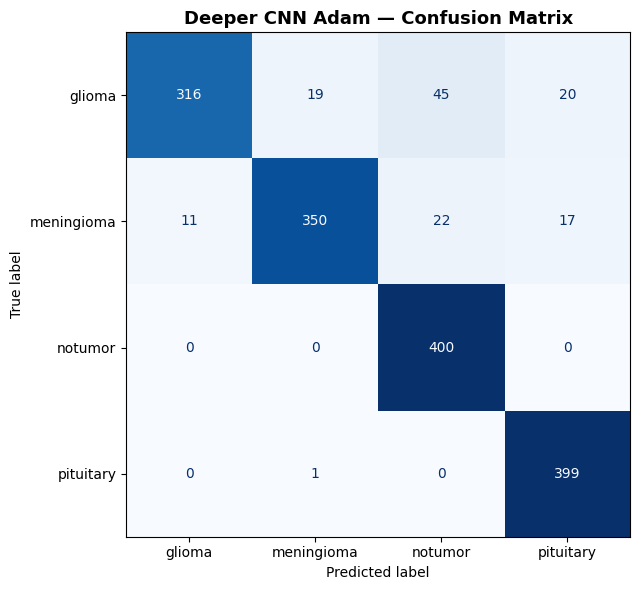


Training Deeper CNN (SGD)...
Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 50s 275ms/step - accuracy: 0.5667 - loss: 1.0828 - val_accuracy: 0.3089 - val_loss: 1.5272 - learning_rate: 0.0100
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.7071 - loss: 0.7643 - val_accuracy: 0.4884 - val_loss: 1.2682 - learning_rate: 0.0100
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7469 - loss: 0.6590
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.7404 - loss: 0.6808 - val_accuracy: 0.4277 - val_loss: 1.4036 - learning_rate: 0.0100
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 274ms/step - accuracy: 0.7681 - loss: 0.6057 - val_accuracy: 0.5437 - val_loss: 1.1576 - learning_rate: 0.0050
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.7801 - loss: 0.5606 - val_accuracy: 0.4866 - val_loss: 1.4728 - learning_rate: 0.0050
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 

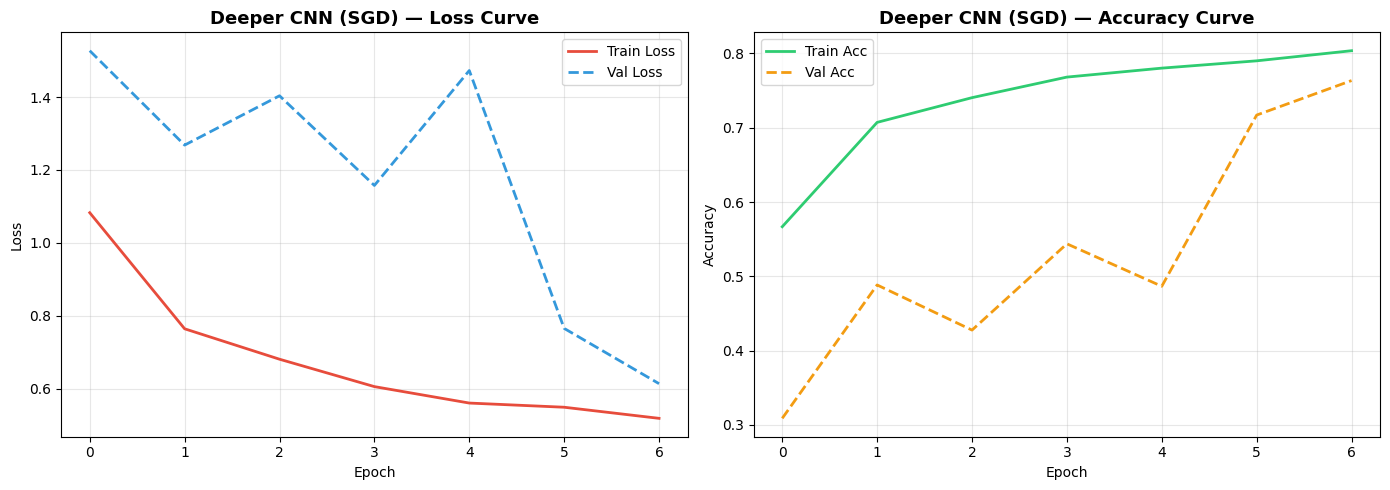

Deeper CNN (SGD) Test Accuracy: 30.63%
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step

Evaluation: Deeper CNN SGD
              precision    recall  f1-score   support

      glioma       0.60      0.01      0.01       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.30      0.88      0.44       400
   pituitary       0.34      0.34      0.34       400

    accuracy                           0.31      1600
   macro avg       0.31      0.31      0.20      1600
weighted avg       0.31      0.31      0.20      1600



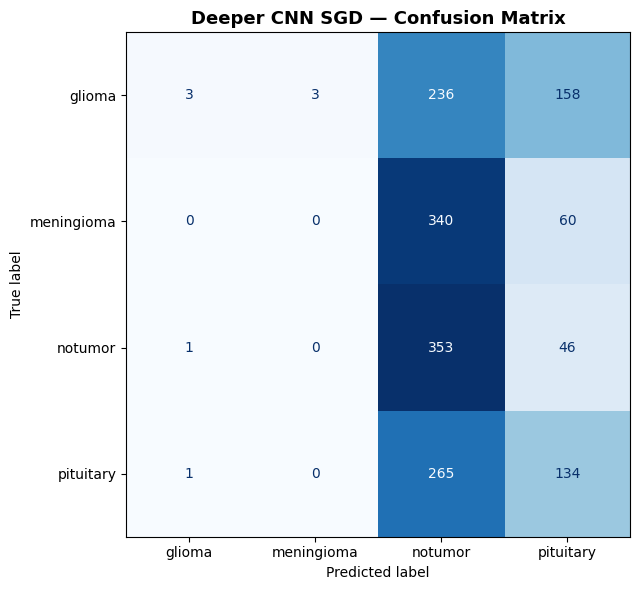

(array([2, 3, 3, ..., 0, 2, 2]), array([0, 0, 0, ..., 3, 3, 3], dtype=int32))

In [15]:
# ============================================================
# PART A — STEP 2: DEEPER CNN WITH REGULARIZATION
# ============================================================
def build_deeper_cnn(num_classes):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Conv Block 4 (extra depth)
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# --- Train with ADAM ---
deeper_model_adam = build_deeper_cnn(NUM_CLASSES)
deeper_model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model_adam.summary()

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("\nTraining Deeper CNN (Adam)...")
start_time = time.time()
history_deeper_adam = deeper_model_adam.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks_deeper,
    verbose=1
)
deeper_adam_time = time.time() - start_time
print(f"Deeper CNN (Adam) training time: {deeper_adam_time:.1f}s ({deeper_adam_time/60:.1f} min)")

plot_history(history_deeper_adam, 'Deeper CNN (Adam)', 'history_deeper_adam')

_, deeper_adam_acc = deeper_model_adam.evaluate(test_generator, verbose=0)
print(f"Deeper CNN (Adam) Test Accuracy: {deeper_adam_acc*100:.2f}%")
evaluate_model(deeper_model_adam, test_generator, 'Deeper CNN Adam')

# --- Train with SGD ---
deeper_model_sgd = build_deeper_cnn(NUM_CLASSES)
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Deeper CNN (SGD)...")
start_time = time.time()
history_deeper_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks_deeper,
    verbose=1
)
deeper_sgd_time = time.time() - start_time
print(f"Deeper CNN (SGD) training time: {deeper_sgd_time:.1f}s ({deeper_sgd_time/60:.1f} min)")

plot_history(history_deeper_sgd, 'Deeper CNN (SGD)', 'history_deeper_sgd')

_, deeper_sgd_acc = deeper_model_sgd.evaluate(test_generator, verbose=0)
print(f"Deeper CNN (SGD) Test Accuracy: {deeper_sgd_acc*100:.2f}%")
evaluate_model(deeper_model_sgd, test_generator, 'Deeper CNN SGD')


Training Ablation Model (No Dropout)...
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 253ms/step - accuracy: 0.7121 - loss: 0.7324 - val_accuracy: 0.2830 - val_loss: 1.9077 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.8188 - loss: 0.4704 - val_accuracy: 0.3045 - val_loss: 2.7131 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8545 - loss: 0.3862
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 280ms/step - accuracy: 0.8574 - loss: 0.3839 - val_accuracy: 0.4384 - val_loss: 3.9104 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 238ms/step - accuracy: 0.8978 - loss: 0.2829 - val_accuracy: 0.6018 - val_loss: 1.2344 - learning_rate: 5.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 242ms/step - accuracy: 0.9098 - loss: 0.2369 - val_accuracy: 0.7357 - val_loss: 0.7132 - learning_rate: 5.0000e-04
Epoch 6/30
140/140 ━━━━

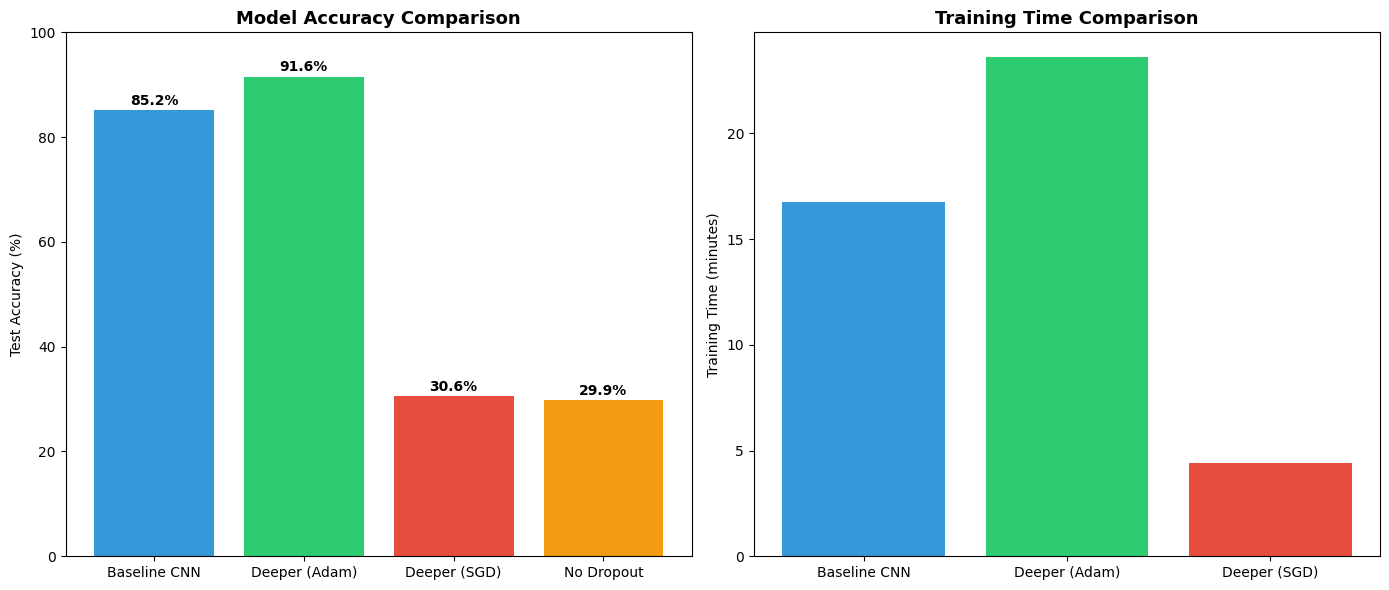

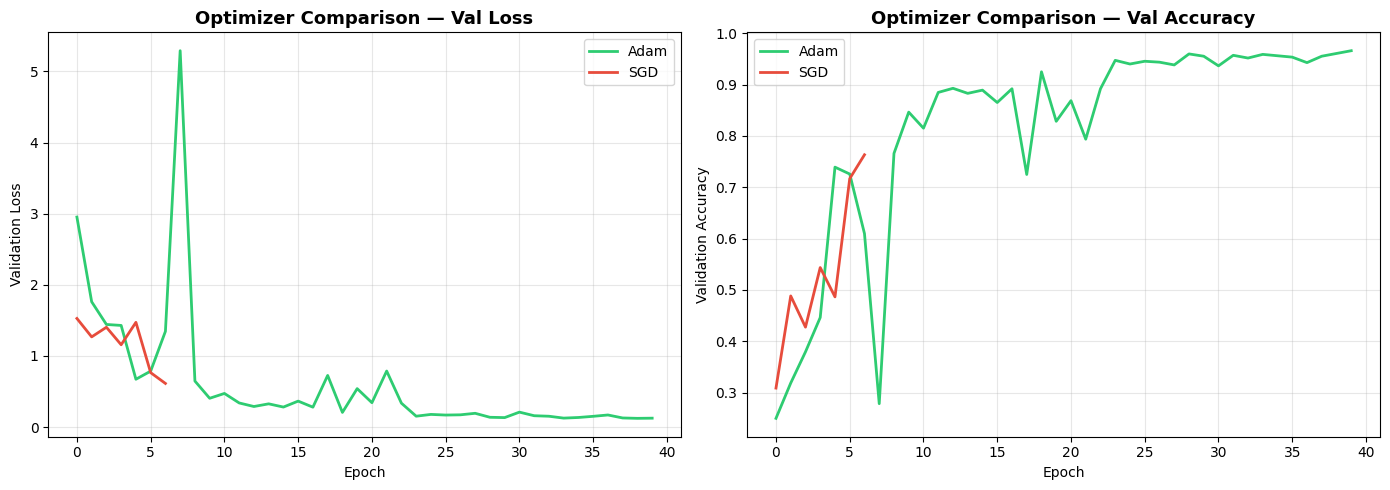


 PART A COMPLETE


In [17]:
# ============================================================
# PART A — STEP 3: ABLATION STUDY (remove dropout)
# ============================================================
def build_no_dropout_cnn(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

ablation_model = build_no_dropout_cnn(NUM_CLASSES)
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Ablation Model (No Dropout)...")
history_ablation = ablation_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_deeper,
    verbose=1
)

_, ablation_acc = ablation_model.evaluate(test_generator, verbose=0)
print(f"Ablation (No Dropout) Test Accuracy: {ablation_acc*100:.2f}%")

# ============================================================
# COMPARATIVE ANALYSIS PLOT
# ============================================================
model_names = ['Baseline CNN', 'Deeper (Adam)', 'Deeper (SGD)', 'No Dropout']
accuracies   = [baseline_acc, deeper_adam_acc, deeper_sgd_acc, ablation_acc]
train_times  = [baseline_train_time, deeper_adam_time, deeper_sgd_time, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars = axes[0].bar(model_names, [a*100 for a in accuracies],
                   color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{acc*100:.1f}%', ha='center', fontweight='bold')

axes[1].bar(model_names[:3], [t/60 for t in train_times[:3]],
            color=['#3498db','#2ecc71','#e74c3c'])
axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Training Time (minutes)')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_deeper_adam.history['val_loss'], label='Adam', color='#2ecc71', linewidth=2)
axes[0].plot(history_deeper_sgd.history['val_loss'],  label='SGD',  color='#e74c3c', linewidth=2)
axes[0].set_title('Optimizer Comparison — Val Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper_adam.history['val_accuracy'], label='Adam', color='#2ecc71', linewidth=2)
axes[1].plot(history_deeper_sgd.history['val_accuracy'],  label='SGD',  color='#e74c3c', linewidth=2)
axes[1].set_title('Optimizer Comparison — Val Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n PART A COMPLETE")

 Libraries imported successfully
 Image size set to: (224, 224)
 Data generators created

 Loading training dataset...
Found 4480 images belonging to 4 classes.

 Loading validation dataset...
Found 1120 images belonging to 4 classes.

 Loading testing dataset...
Found 1600 images belonging to 4 classes.
 Dataset loading complete

 Loading ResNet50 pretrained model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
 ResNet50 model loaded successfully
 Base model layers frozen

 Building custom classifier...
 Custom classifier added

 Compiling model...
 Model compiled successfully

 MODEL SUMMARY
Total params: 24,771,204
Trainable params: 1,182,468
 Callbacks configured

PHASE 1 — FEATURE EXTRACTION TRAINING
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 600ms/step - accuracy: 0.6107 - loss: 0.9765 - val_accuracy: 0.2545 - val_loss: 1.8482 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 547ms/step - accuracy: 0.6661 - loss: 0.8346 - val_accuracy: 0.4375 - val_loss:

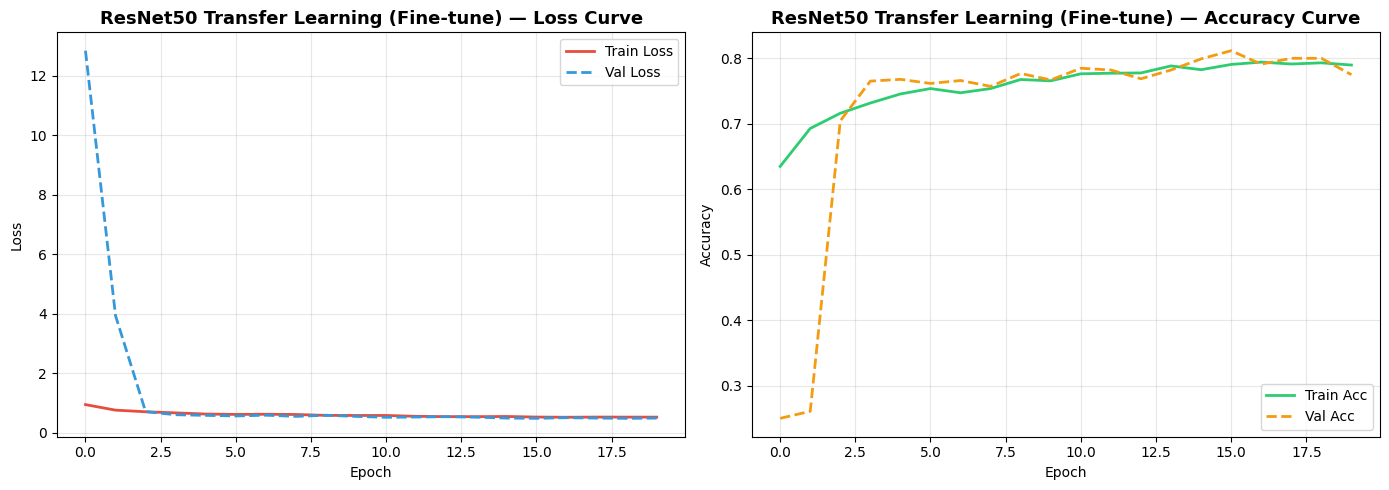

 Graph plotting complete

 Evaluating model on test dataset...

 ResNet50 Transfer Learning Test Accuracy: 75.56%

 Generating detailed evaluation report...
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step

Evaluation: ResNet50 Transfer Learning
              precision    recall  f1-score   support

      glioma       0.84      0.52      0.64       400
  meningioma       0.68      0.54      0.60       400
     notumor       0.74      0.98      0.84       400
   pituitary       0.77      0.99      0.87       400

    accuracy                           0.76      1600
   macro avg       0.76      0.76      0.74      1600
weighted avg       0.76      0.76      0.74      1600



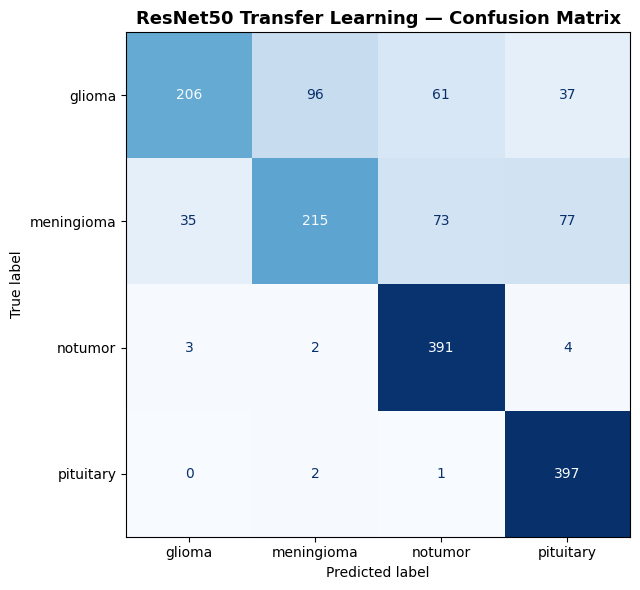

 Evaluation complete

FINAL MODEL COMPARISON SUMMARY
Baseline CNN:               85.19%
Deeper CNN (Adam):          91.56%
Deeper CNN (SGD):           30.63%
Ablation (No Dropout):      29.88%
ResNet50 Transfer Learning: 75.56%

 PART B COMPLETE — ALL VISION TASKS DONE
 Brain Tumor MRI Classification Project Finished Successfully


In [18]:
# PART B — TRANSFER LEARNING WITH ResNet50

# -----------------------------------------------------------
# Importing Required Libraries
# -----------------------------------------------------------
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

print(" Libraries imported successfully")


# -----------------------------------------------------------
# Defining Image Size for Transfer Learning
# ResNet50 requires 224x224 images
# -----------------------------------------------------------
IMG_SIZE_TL = (224, 224)

print(" Image size set to:", IMG_SIZE_TL)


# -----------------------------------------------------------
# Data Augmentation for Training
# Helps reduce overfitting and improve generalization
# -----------------------------------------------------------
tl_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

# Only rescaling for testing
tl_test_datagen = ImageDataGenerator(rescale=1./255)

print(" Data generators created")


# -----------------------------------------------------------
# Loading Training Dataset
# -----------------------------------------------------------
print("\n Loading training dataset...")

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)


# -----------------------------------------------------------
# Loading Validation Dataset
# -----------------------------------------------------------
print("\n Loading validation dataset...")

tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)


# -----------------------------------------------------------
# Loading Testing Dataset
# -----------------------------------------------------------
print("\n Loading testing dataset...")

tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(" Dataset loading complete")


# -----------------------------------------------------------
# Loading Pretrained ResNet50 Base Model
# include_top=False removes original classifier
# -----------------------------------------------------------
print("\n Loading ResNet50 pretrained model...")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print(" ResNet50 model loaded successfully")


# -----------------------------------------------------------
# Freezing Base Model Layers
# Feature Extraction Phase
# -----------------------------------------------------------
base_model.trainable = False

print(" Base model layers frozen")


# -----------------------------------------------------------
# Building Custom Classification Head
# -----------------------------------------------------------
print("\n Building custom classifier...")

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

# Creating final model
tl_model = Model(inputs=base_model.input, outputs=output)

print(" Custom classifier added")


# -----------------------------------------------------------
# Compiling Model
# -----------------------------------------------------------
print("\n Compiling model...")

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully")


# -----------------------------------------------------------
# Displaying Model Information
# -----------------------------------------------------------
print("\n MODEL SUMMARY")
print("="*50)

print(f"Total params: {tl_model.count_params():,}")

print(f"Trainable params: "
      f"{sum([np.prod(v.shape) for v in tl_model.trainable_variables]):,}")

print("="*50)


# -----------------------------------------------------------
# Defining Callbacks
# EarlyStopping prevents overfitting
# ReduceLROnPlateau lowers learning rate automatically
# -----------------------------------------------------------
callbacks_tl = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        verbose=1
    )
]

print(" Callbacks configured")


# -----------------------------------------------------------
# PHASE 1 TRAINING
# Feature Extraction
# -----------------------------------------------------------
print("\n" + "="*60)
print("PHASE 1 — FEATURE EXTRACTION TRAINING")
print("="*60)

start_time = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    callbacks=callbacks_tl,
    verbose=1
)

phase1_time = time.time() - start_time

print(f"\n Phase 1 completed in {phase1_time/60:.1f} minutes")


# -----------------------------------------------------------
# Fine Tuning
# Unfreeze top 30 layers
# -----------------------------------------------------------
print("\n Unfreezing top 30 layers for fine-tuning...")

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print(" Top 30 layers unfrozen")


# -----------------------------------------------------------
# Recompiling Model with Smaller Learning Rate
# -----------------------------------------------------------
print("\n Recompiling model for fine-tuning...")

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Fine-tuning model compiled")


# -----------------------------------------------------------
# PHASE 2 TRAINING
# Fine-Tuning
# -----------------------------------------------------------
print("\n" + "="*60)
print("PHASE 2 — FINE TUNING")
print("="*60)

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    callbacks=callbacks_tl,
    verbose=1
)

tl_total_time = time.time() - start_time + phase1_time

print(f"\n Transfer Learning Total Time: "
      f"{tl_total_time:.1f}s ({tl_total_time/60:.1f} min)")


# -----------------------------------------------------------
# Plotting Training Graphs
# -----------------------------------------------------------
print("\n Plotting training graphs...")

plot_history(
    history_tl_phase2,
    'ResNet50 Transfer Learning (Fine-tune)',
    'history_resnet'
)

print(" Graph plotting complete")


# -----------------------------------------------------------
# Evaluating Model on Test Dataset
# -----------------------------------------------------------
print("\n Evaluating model on test dataset...")

_, tl_acc = tl_model.evaluate(tl_test_gen, verbose=0)

print(f"\n ResNet50 Transfer Learning Test Accuracy: "
      f"{tl_acc*100:.2f}%")


# -----------------------------------------------------------
# Detailed Evaluation
# Confusion Matrix + Classification Report
# -----------------------------------------------------------
print("\n Generating detailed evaluation report...")

evaluate_model(
    tl_model,
    tl_test_gen,
    'ResNet50 Transfer Learning'
)

print(" Evaluation complete")


# -----------------------------------------------------------
# Final Comparison of All Models
# -----------------------------------------------------------
print("\n" + "="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)

print(f"Baseline CNN:               {baseline_acc*100:.2f}%")
print(f"Deeper CNN (Adam):          {deeper_adam_acc*100:.2f}%")
print(f"Deeper CNN (SGD):           {deeper_sgd_acc*100:.2f}%")
print(f"Ablation (No Dropout):      {ablation_acc*100:.2f}%")
print(f"ResNet50 Transfer Learning: {tl_acc*100:.2f}%")

print("="*60)


# -----------------------------------------------------------
# Completion Message
# -----------------------------------------------------------
print("\n PART B COMPLETE — ALL VISION TASKS DONE")
print(" Brain Tumor MRI Classification Project Finished Successfully")